# Article Plan - Fourier Trade-off Experiments

This notebook isolates the new paper direction:

- empirical local spectral concentration (first harmonic dominance),
- cost vs accuracy trade-off,
- failure modes (local vs global),
- minimal generality across ansatz families.

Main reframe:

We do not claim a new Fourier method for VQE. We test when a cheap K=1 surrogate is enough, and where it breaks.

## Simulation roadmap (prioritized)

P0 (must-have):
1. Local vs global spectrum (H2, LiH, BeH2).
2. R1 and normalized spectral entropy as headline metrics.
3. Error vs harmonic order K (K=1,2,3,full).
4. Cost vs error: default VQE vs K=1 guided vs fuller reconstruction (proxy of higher cost).

P1 (strong extra):
5. Ansatz generality: RealAmplitudes vs EfficientSU2 (and UCCSD if runtime allows).

P2 (optional):
6. Expanded molecules or wider geometry ranges.

In [1]:
import pandas as pd

plan_df = pd.DataFrame([
    {"experiment": "Local vs global spectrum", "priority": "P0", "runtime_risk": "low", "main_output": "Figure 1"},
    {"experiment": "R1 + entropy summary", "priority": "P0", "runtime_risk": "low", "main_output": "Figure 2"},
    {"experiment": "Error vs K (1,2,3,full)", "priority": "P0", "runtime_risk": "medium", "main_output": "Figure 3"},
    {"experiment": "Cost vs error across methods", "priority": "P0", "runtime_risk": "medium", "main_output": "Figure 4"},
    {"experiment": "Ansatz ablation (RealAmplitudes/EfficientSU2/UCCSD)", "priority": "P1", "runtime_risk": "high", "main_output": "Table A"},
])

plan_df

,experiment,priority,runtime_risk,main_output
0,Local vs global spectrum,P0,low,Figure 1
1,R1 + entropy summary,P0,low,Figure 2
2,"Error vs K (1,2,3,full)",P0,medium,Figure 3
3,Cost vs error across methods,P0,medium,Figure 4
4,Ansatz ablation (RealAmplitudes/EfficientSU2/U...,P1,high,Table A


## Shared config

Use a small but representative setup first. Increase only after sanity checks.

In [29]:
import numpy as np

SYSTEMS = {
    "H2": {
        "basis": "sto-3g",
        "active_space": (2, 2),
        "active_orbitals": None,
        "freeze_core": False,
        "mapper": "parity",
        "z2": True,
        # "distances": np.array([0.6, 0.9, 1.2, 1.6, 2.0, 2.4], dtype=float),
       "distances": np.linspace(0.5, 2.5, 14),
        "geom": lambda d: f"H 0 0 0; H 0 0 {float(d)}",
    },
    "LiH": {
        "basis": "sto-3g",
        "active_space": (2, 3),
        "active_orbitals": [0, 1, 2],
        "freeze_core": True,
        "mapper": "parity",
        "z2": True,
        # "distances": np.array([0.6, 0.9, 1.2, 1.6, 2.0, 2.4], dtype=float),
        "distances": np.linspace(0.5, 2.5, 14),
        "geom": lambda d: f"Li 0 0 0; H 0 0 {float(d)}",
    },
    "BeH2": {
        "basis": "sto-3g",
        "active_space": (4, 4),
        "active_orbitals": [0, 1, 2, 3],
        "freeze_core": True,
        "mapper": "parity",
        "z2": True,
        # "distances": np.array([0.6, 0.9, 1.2, 1.6, 2.0, 2.4], dtype=float),
        "distances": np.linspace(0.5, 2.5, 14),
        "geom": lambda d: f"Be 0 0 0; H 0 0 {float(d)}; H 0 0 {-float(d)}",
    },
}

ANSATZ_LIST = [
    {"name": "real_amplitudes", "reps": 2},
    {"name": "efficient_su2", "reps": 2},
]

HARMONIC_GRID = [1, 2, 3]
THETA_SAMPLES = 64
SEED = 137

print("Systems:", list(SYSTEMS.keys()))
print("Ansatz list:", ANSATZ_LIST)

Systems: ['H2', 'LiH', 'BeH2']
Ansatz list: [{'name': 'real_amplitudes', 'reps': 2}, {'name': 'efficient_su2', 'reps': 2}]


## Figure mapping

- Figure 1: local vs global spectral profiles (selected distances).
- Figure 2: R1 and H_norm vs distance (with uncertainty ribbons).
- Figure 3: error vs harmonic order K.
- Figure 4: cost (eval_count or function calls) vs error for methods.

In [30]:
# This cell stores a concrete execution checklist and status tracking.
checklist_df = pd.DataFrame([
    {"task": "Figure 1 - local/global spectra", "status": "todo"},
    {"task": "Figure 2 - R1 and H_norm", "status": "todo"},
    {"task": "Figure 3 - error vs K", "status": "todo"},
    {"task": "Figure 4 - cost vs error", "status": "todo"},
    {"task": "Ansatz ablation table", "status": "todo"},
])

checklist_df

,task,status
0,Figure 1 - local/global spectra,todo
1,Figure 2 - R1 and H_norm,todo
2,Figure 3 - error vs K,todo
3,Figure 4 - cost vs error,todo
4,Ansatz ablation table,todo


## Notes for writing

Positioning sentence:

This work does not introduce the Fourier description of VQE landscapes, which is known, but shows that in small molecular systems the local directional spectrum is often strongly concentrated in the first harmonic, enabling a cheaper surrogate that replaces exact trigonometric reconstruction with little loss in accuracy.

Claim boundary:
- local empirical regularity,
- practical trade-off,
- not a universal theorem.

## P0 execution (run now)

This block runs the mandatory P0 experiments:
- Figure 1: local vs global spectrum,
- Figure 2: R1 and H_norm vs distance,
- Figure 3: error vs harmonic order K,
- Figure 4: cost vs error across methods.

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit.quantum_info import Statevector
from qiskit_algorithms.minimum_eigensolvers import NumPyMinimumEigensolver

from src.vqe.ansatz import build_ansatz
from src.vqe.optimizer import get_optimizer
from src.vqe.vqe_runner import run_vqe
from src.vqe.hamiltonian import (
    build_electronic_problem,
    build_electronic_hamiltonian,
    build_qubit_hamiltonian,
)

# P0 uses one ansatz family to isolate the spectral trade-off claim.
P0_ANSATZ = {"name": "real_amplitudes", "reps": 2}
P0_MAX_ITER = 450
P0_THETA_SAMPLES = 64
P0_SEED = 137
P0_GLOBAL_SAMPLES = 4
P0_K_GRID = [1, 2, 3]

def _wrap_pi(x: np.ndarray) -> np.ndarray:
    return ((x + np.pi) % (2 * np.pi)) - np.pi

def _build_qubit_instance(cfg: dict, d: float):
    atom = cfg["geom"](float(d))
    problem = build_electronic_problem(
        atom_string=atom,
        basis=cfg["basis"],
        active_space=cfg["active_space"],
        active_orbitals=cfg["active_orbitals"],
        freeze_core=cfg["freeze_core"],
    )
    ferm_op, const_energy = build_electronic_hamiltonian(
        atom_string=atom,
        basis=cfg["basis"],
        active_space=cfg["active_space"],
        active_orbitals=cfg["active_orbitals"],
        freeze_core=cfg["freeze_core"],
    )
    qubit_op = build_qubit_hamiltonian(
        ferm_op,
        mapper=cfg["mapper"],
        z2symmetry_reduction=cfg["z2"],
        problem=problem,
        num_particles=problem.num_particles,
    ).simplify(atol=0.0)
    return problem, qubit_op, float(const_energy)

def _energy_line(ansatz, qubit_op, const_energy, center, direction, theta_grid):
    params = list(ansatz.parameters)
    values = []
    for t in theta_grid:
        p = _wrap_pi(center + float(t) * direction)
        bind = {params[i]: float(p[i]) for i in range(len(params))}
        state = Statevector.from_instruction(ansatz.assign_parameters(bind))
        values.append(float(np.real(state.expectation_value(qubit_op)) + const_energy))
    return np.asarray(values, dtype=float)

def _fft_series(y: np.ndarray):
    n = len(y)
    fft_r = np.fft.rfft(y) / n
    a0_half = float(fft_r[0].real)
    ak = 2.0 * np.real(fft_r[1:])
    bk = -2.0 * np.imag(fft_r[1:])
    return a0_half, ak, bk

def _reconstruct(theta_grid, a0_half, ak, bk, kmax):
    kmax = int(min(kmax, len(ak)))
    rec = np.full(theta_grid.shape, a0_half, dtype=float)
    for k in range(1, kmax + 1):
        rec += ak[k - 1] * np.cos(k * theta_grid) + bk[k - 1] * np.sin(k * theta_grid)
    return rec

def _spectral_metrics(ak, bk):
    amp2 = np.asarray(ak, dtype=float) ** 2 + np.asarray(bk, dtype=float) ** 2
    total = float(np.sum(amp2))
    if total <= 0.0:
        return {"r1": 1.0, "h_norm": 0.0}
    p = amp2 / total
    eps = 1e-16
    h = float(-np.sum(p * np.log(p + eps)))
    h_norm = float(h / np.log(len(p))) if len(p) > 1 else 0.0
    r1 = float(p[0]) if len(p) > 0 else 1.0
    return {"r1": r1, "h_norm": h_norm}

print("P0 helpers ready.")

P0 helpers ready.


,system,distance,regime,r1,h_norm
0,H2,0.500000,local,1.000000,2.696536e-30
1,H2,0.500000,global,0.677430,3.044557e-01
2,H2,0.500000,global,0.992108,1.721888e-02
3,H2,0.500000,global,0.901300,1.380500e-01
4,H2,0.500000,global,0.646260,4.142145e-01
5,H2,0.653846,local,1.000000,4.369143e-30
6,H2,0.653846,global,0.810981,2.552662e-01
7,H2,0.653846,global,0.644845,4.154279e-01
8,H2,0.653846,global,0.958500,6.106980e-02
9,H2,0.653846,global,0.986633,2.806594e-02


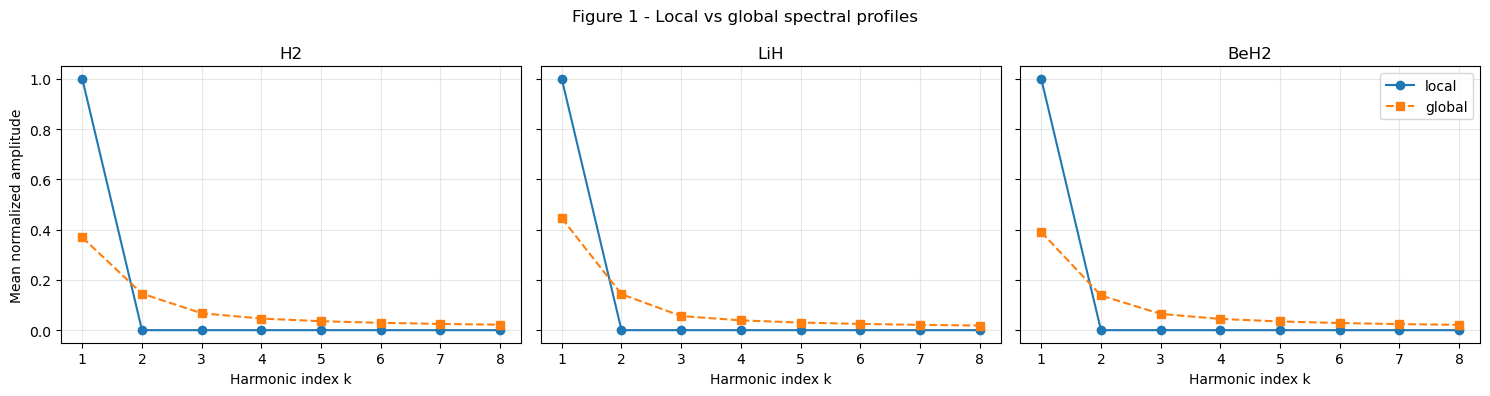

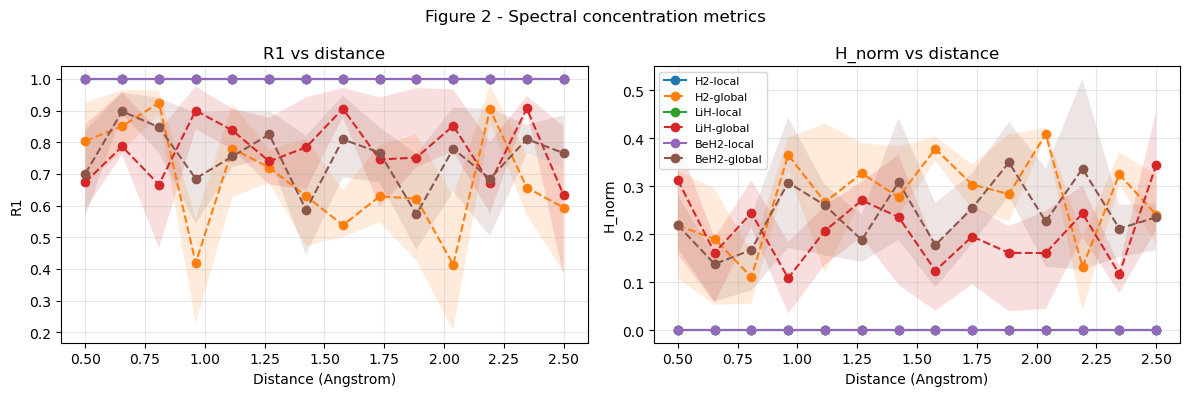

In [36]:
# Figure 1 + Figure 2 data: local vs global spectral profile and R1/H_norm vs distance
rng = np.random.default_rng(P0_SEED)
theta_grid = np.linspace(0.0, 2.0 * np.pi, P0_THETA_SAMPLES, endpoint=False)

rows_spectral = []
rows_profile = []

for system_name, cfg in SYSTEMS.items():
    for d in cfg["distances"]:
        d = float(d)
        _, qubit_op, const_energy = _build_qubit_instance(cfg, d)

        ansatz = build_ansatz(
            name=P0_ANSATZ["name"],
            num_qubits=qubit_op.num_qubits,
            reps=P0_ANSATZ["reps"],
        )
        n_params = ansatz.num_parameters
        if n_params == 0:
            continue

        optimizer = get_optimizer("cobyla", max_iter=P0_MAX_ITER)
        vqe_res = run_vqe(
            qubit_op=qubit_op,
            ansatz=ansatz,
            optimizer=optimizer,
            constant_energy=const_energy,
            seed=P0_SEED,
        )
        if not vqe_res.get("success", False):
            continue

        p_star = np.asarray(vqe_res["optimal_params"], dtype=float)
        local_dir = np.eye(n_params)[0]
        local_line = _energy_line(ansatz, qubit_op, const_energy, p_star, local_dir, theta_grid)
        a0_l, ak_l, bk_l = _fft_series(local_line)
        m_l = _spectral_metrics(ak_l, bk_l)

        rows_spectral.append({
            "system": system_name,
            "distance": d,
            "regime": "local",
            "r1": m_l["r1"],
            "h_norm": m_l["h_norm"],
        })

        amp_l = np.sqrt(ak_l ** 2 + bk_l ** 2)
        amp_l = amp_l / (np.sum(amp_l) + 1e-16)
        for k in range(min(8, len(amp_l))):
            rows_profile.append({
                "system": system_name,
                "distance": d,
                "regime": "local",
                "k": k + 1,
                "norm_amp": float(amp_l[k]),
            })

        for _ in range(P0_GLOBAL_SAMPLES):
            center = rng.uniform(-np.pi, np.pi, size=n_params)
            direction = rng.normal(size=n_params)
            direction = direction / (np.linalg.norm(direction) + 1e-12)
            global_line = _energy_line(ansatz, qubit_op, const_energy, center, direction, theta_grid)
            _, ak_g, bk_g = _fft_series(global_line)
            m_g = _spectral_metrics(ak_g, bk_g)

            rows_spectral.append({
                "system": system_name,
                "distance": d,
                "regime": "global",
                "r1": m_g["r1"],
                "h_norm": m_g["h_norm"],
            })

            amp_g = np.sqrt(ak_g ** 2 + bk_g ** 2)
            amp_g = amp_g / (np.sum(amp_g) + 1e-16)
            for k in range(min(8, len(amp_g))):
                rows_profile.append({
                    "system": system_name,
                    "distance": d,
                    "regime": "global",
                    "k": k + 1,
                    "norm_amp": float(amp_g[k]),
                })

spectral_df = pd.DataFrame(rows_spectral)
profile_df = pd.DataFrame(rows_profile)

display(spectral_df.head(12))

# Figure 1: profile by harmonic index (mean across distances/samples)
profile_plot_df = (
    profile_df.groupby(["system", "regime", "k"], as_index=False)
    .agg(mean_norm_amp=("norm_amp", "mean"))
)

fig, axes = plt.subplots(1, len(SYSTEMS), figsize=(15, 4), sharey=True)
if len(SYSTEMS) == 1:
    axes = [axes]

for ax, system_name in zip(axes, SYSTEMS.keys()):
    for regime, style in [("local", "-o"), ("global", "--s")]:
        sub = profile_plot_df[
            (profile_plot_df["system"] == system_name) & (profile_plot_df["regime"] == regime)
        ].sort_values("k")
        ax.plot(sub["k"], sub["mean_norm_amp"], style, label=regime)
    ax.set_title(system_name)
    ax.set_xlabel("Harmonic index k")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("Mean normalized amplitude")
axes[-1].legend()
plt.suptitle("Figure 1 - Local vs global spectral profiles")
plt.tight_layout()
plt.show()

# Figure 2: R1 and H_norm vs distance
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for system_name in SYSTEMS.keys():
    sub = spectral_df[spectral_df["system"] == system_name]
    for metric, axis, title in [("r1", ax[0], "R1 vs distance"), ("h_norm", ax[1], "H_norm vs distance")]:
        g = (
            sub.groupby(["distance", "regime"], as_index=False)
            .agg(
                mean_val=(metric, "mean"),
                p25=(metric, lambda x: float(np.percentile(x, 25))),
                p75=(metric, lambda x: float(np.percentile(x, 75))),
            )
        )
        for regime, ls in [("local", "-"), ("global", "--")]:
            s = g[g["regime"] == regime].sort_values("distance")
            label = f"{system_name}-{regime}"
            axis.plot(s["distance"], s["mean_val"], ls, marker="o", label=label)
            axis.fill_between(s["distance"], s["p25"], s["p75"], alpha=0.15)
        axis.set_title(title)
        axis.set_xlabel("Distance (Angstrom)")
        axis.grid(alpha=0.3)
ax[0].set_ylabel("R1")
ax[1].set_ylabel("H_norm")
ax[1].legend(fontsize=8)
plt.suptitle("Figure 2 - Spectral concentration metrics")
plt.tight_layout()
plt.show()

,system,distance,K,rmse,delta_emin
0,H2,0.500000,1,4.263857e-16,0.000000e+00
1,H2,0.500000,2,4.098268e-16,0.000000e+00
2,H2,0.500000,3,4.108359e-16,0.000000e+00
3,H2,0.500000,32,2.966073e-16,2.220446e-16
4,H2,0.653846,1,4.269112e-16,0.000000e+00
5,H2,0.653846,2,4.201846e-16,0.000000e+00
6,H2,0.653846,3,4.242423e-16,0.000000e+00
7,H2,0.653846,32,2.809626e-16,4.440892e-16
8,H2,0.807692,1,3.558171e-16,0.000000e+00
9,H2,0.807692,2,3.503098e-16,0.000000e+00


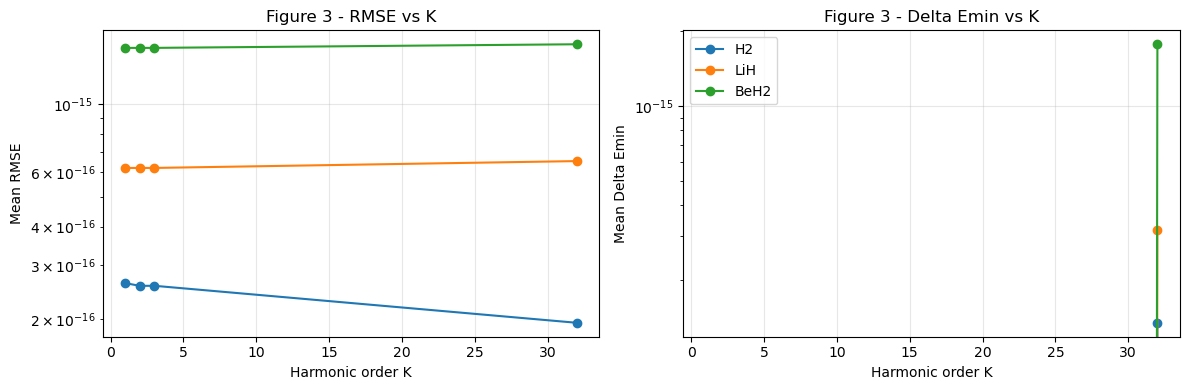

In [37]:
# Figure 3: error vs harmonic order K
rows_k = []

for system_name, cfg in SYSTEMS.items():
    for d in cfg["distances"]:
        d = float(d)
        _, qubit_op, const_energy = _build_qubit_instance(cfg, d)

        ansatz = build_ansatz(
            name=P0_ANSATZ["name"],
            num_qubits=qubit_op.num_qubits,
            reps=P0_ANSATZ["reps"],
        )
        n_params = ansatz.num_parameters
        if n_params == 0:
            continue

        optimizer = get_optimizer("cobyla", max_iter=P0_MAX_ITER)
        vqe_res = run_vqe(
            qubit_op=qubit_op,
            ansatz=ansatz,
            optimizer=optimizer,
            constant_energy=const_energy,
            seed=P0_SEED,
        )
        if not vqe_res.get("success", False):
            continue

        p_star = np.asarray(vqe_res["optimal_params"], dtype=float)
        direction = np.eye(n_params)[0]
        y = _energy_line(ansatz, qubit_op, const_energy, p_star, direction, theta_grid)
        a0_half, ak, bk = _fft_series(y)

        y_full = _reconstruct(theta_grid, a0_half, ak, bk, kmax=len(ak))
        idx_y = int(np.argmin(y))
        e_min_y = float(y[idx_y])

        for k in P0_K_GRID:
            yk = _reconstruct(theta_grid, a0_half, ak, bk, kmax=k)
            rmse = float(np.sqrt(np.mean((y - yk) ** 2)))
            idx_k = int(np.argmin(yk))
            e_min_k = float(y[idx_k])
            delta_emin = float(abs(e_min_k - e_min_y))
            rows_k.append({
                "system": system_name,
                "distance": d,
                "K": int(k),
                "rmse": rmse,
                "delta_emin": delta_emin,
            })

        rmse_full = float(np.sqrt(np.mean((y - y_full) ** 2)))
        delta_full = float(abs(float(np.min(y_full)) - e_min_y))
        rows_k.append({
            "system": system_name,
            "distance": d,
            "K": int(len(ak)),
            "rmse": rmse_full,
            "delta_emin": delta_full,
        })

k_df = pd.DataFrame(rows_k)
display(k_df.head(12))

k_summary = (
    k_df.groupby(["system", "K"], as_index=False)
    .agg(
        mean_rmse=("rmse", "mean"),
        mean_delta_emin=("delta_emin", "mean"),
    )
    .sort_values(["system", "K"])
)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for system_name in SYSTEMS.keys():
    sub = k_summary[k_summary["system"] == system_name].sort_values("K")
    ax[0].plot(sub["K"], sub["mean_rmse"], marker="o", label=system_name)
    ax[1].plot(sub["K"], sub["mean_delta_emin"], marker="o", label=system_name)
ax[0].set_xlabel("Harmonic order K")
ax[0].set_ylabel("Mean RMSE")
ax[0].set_yscale("log")
ax[0].set_title("Figure 3 - RMSE vs K")
ax[0].grid(alpha=0.3)
ax[1].set_xlabel("Harmonic order K")
ax[1].set_ylabel("Mean Delta Emin")
ax[1].set_yscale("log")
ax[1].set_title("Figure 3 - Delta Emin vs K")
ax[1].grid(alpha=0.3)
ax[1].legend()
plt.tight_layout()
plt.show()

,system,distance,mode,eval_count,guide_cost,total_cost,abs_error
0,H2,0.500000,default,35,0,35.0,9.767960e-10
1,H2,0.500000,guided,29,3,32.0,4.440892e-16
2,H2,0.653846,default,39,0,39.0,2.579700e-09
3,H2,0.653846,guided,29,3,32.0,4.440892e-16
4,H2,0.807692,default,36,0,36.0,3.831238e-10
5,H2,0.807692,guided,29,3,32.0,0.000000e+00
6,H2,0.961538,default,40,0,40.0,1.235446e-09
7,H2,0.961538,guided,29,3,32.0,0.000000e+00
8,H2,1.115385,default,37,0,37.0,1.033506e-09
9,H2,1.115385,guided,29,3,32.0,4.440892e-16


,system,mode,mean_total_cost,mean_abs_error
0,BeH2,default,450.000000,4.887528e-02
1,BeH2,guided,408.071429,4.847649e-02
2,H2,default,35.928571,8.539567e-10
3,H2,guided,32.214286,2.061843e-16
4,LiH,default,450.000000,8.914825e-04
5,LiH,guided,453.000000,5.796317e-04


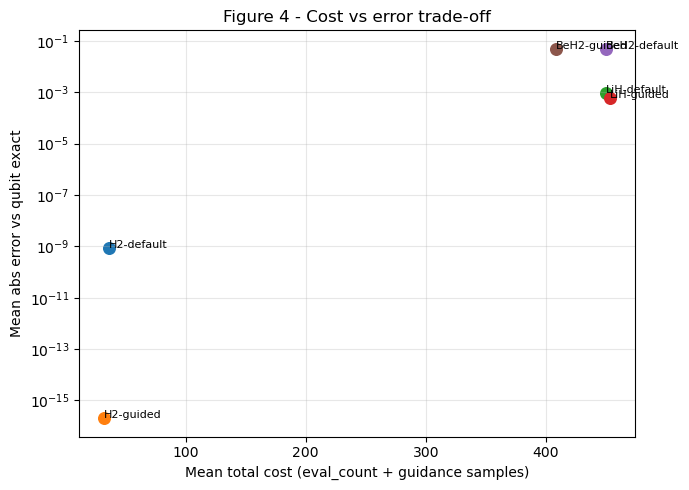

In [38]:
# Figure 4: cost vs error (default vs analytic-guided)
rows_cost = []

def _guided_point(ansatz, qubit_op, const_energy, p_center):
    # No dense sweep: estimate first-harmonic coefficients from 3 samples
    # and use the analytic minimizer theta* = atan2(b1, a1) + pi.
    params = list(ansatz.parameters)
    n_params = len(params)
    direction = np.eye(n_params)[0]

    probe_thetas = [0.0, np.pi / 2.0, -np.pi / 2.0]
    y_probe = _energy_line(ansatz, qubit_op, const_energy, p_center, direction, probe_thetas)

    f0 = float(y_probe[0])
    f_p = float(y_probe[1])
    f_m = float(y_probe[2])

    a0 = 0.5 * (f_p + f_m)
    b1 = 0.5 * (f_p - f_m)
    a1 = f0 - a0
    theta_star = float(np.arctan2(b1, a1) + np.pi)

    return _wrap_pi(p_center + theta_star * direction), len(probe_thetas)

for system_name, cfg in SYSTEMS.items():
    for d in cfg["distances"]:
        d = float(d)
        _, qubit_op, const_energy = _build_qubit_instance(cfg, d)

        ansatz = build_ansatz(
            name=P0_ANSATZ["name"],
            num_qubits=qubit_op.num_qubits,
            reps=P0_ANSATZ["reps"],
        )
        n_params = ansatz.num_parameters
        if n_params == 0:
            continue

        exact = NumPyMinimumEigensolver().compute_minimum_eigenvalue(qubit_op)
        exact_total = float(np.real(exact.eigenvalue) + const_energy)

        opt_probe = get_optimizer("cobyla", max_iter=P0_MAX_ITER)
        probe = run_vqe(
            qubit_op=qubit_op,
            ansatz=ansatz,
            optimizer=opt_probe,
            constant_energy=const_energy,
            seed=P0_SEED,
        )
        if not probe.get("success", False):
            continue
        p_center = np.asarray(probe["optimal_params"], dtype=float)

        p_guided, c_guided = _guided_point(ansatz, qubit_op, const_energy, p_center)
        modes = [
            ("default", None, 0),
            ("guided", p_guided, c_guided),
        ]

        for mode, init_point, guide_cost in modes:
            optimizer = get_optimizer("cobyla", max_iter=P0_MAX_ITER)
            kwargs = {
                "qubit_op": qubit_op,
                "ansatz": ansatz,
                "optimizer": optimizer,
                "constant_energy": const_energy,
                "seed": P0_SEED,
            }
            if init_point is not None:
                kwargs["initial_point"] = np.asarray(init_point, dtype=float)

            res = run_vqe(**kwargs)
            if not res.get("success", False):
                continue

            eval_count = int(res.get("eval_count", 0))
            total_cost = float(eval_count + guide_cost)
            abs_error = float(abs(float(res["energy"]) - exact_total))

            rows_cost.append({
                "system": system_name,
                "distance": d,
                "mode": mode,
                "eval_count": eval_count,
                "guide_cost": int(guide_cost),
                "total_cost": total_cost,
                "abs_error": abs_error,
            })

cost_df = pd.DataFrame(rows_cost)
display(cost_df.head(12))

cost_summary = (
    cost_df.groupby(["system", "mode"], as_index=False)
    .agg(
        mean_total_cost=("total_cost", "mean"),
        mean_abs_error=("abs_error", "mean"),
    )
)
display(cost_summary)

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
for system_name in SYSTEMS.keys():
    sub = cost_summary[cost_summary["system"] == system_name]
    for _, row in sub.iterrows():
        ax.scatter(row["mean_total_cost"], row["mean_abs_error"], s=70)
        ax.text(
            row["mean_total_cost"],
            row["mean_abs_error"],
            f"{system_name}-{row['mode']}",
            fontsize=8,
        )
ax.set_xlabel("Mean total cost (eval_count + guidance samples)")
ax.set_ylabel("Mean abs error vs qubit exact")
ax.set_yscale("log")
ax.set_title("Figure 4 - Cost vs error trade-off")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# Mark P0 checklist as done after successful execution.
if "checklist_df" in globals():
    checklist_df.loc[checklist_df["task"].isin([
        "Figure 1 - local/global spectra",
        "Figure 2 - R1 and H_norm",
        "Figure 3 - error vs K",
        "Figure 4 - cost vs error",
    ]), "status"] = "done"
    display(checklist_df)
else:
    print("Run the checklist cell first to track status.")

,task,status
0,Figure 1 - local/global spectra,done
1,Figure 2 - R1 and H_norm,done
2,Figure 3 - error vs K,done
3,Figure 4 - cost vs error,done
4,Ansatz ablation table,todo


In [39]:
# Compact numeric summary for P0 report text
print("P0 modes found in cost_df:", sorted(cost_df["mode"].unique().tolist()))
display(cost_summary.sort_values(["system", "mode"]))

display(
    spectral_df.groupby(["system", "regime"], as_index=False)
    .agg(mean_r1=("r1", "mean"), mean_h_norm=("h_norm", "mean"))
    .sort_values(["system", "regime"])
 )

display(
    k_df.groupby(["system", "K"], as_index=False)
    .agg(mean_rmse=("rmse", "mean"), mean_delta_emin=("delta_emin", "mean"))
    .sort_values(["system", "K"])
    .head(20)
 )

P0 modes found in cost_df: ['default', 'guided']


,system,mode,mean_total_cost,mean_abs_error
0,BeH2,default,450.000000,4.887528e-02
1,BeH2,guided,408.071429,4.847649e-02
2,H2,default,35.928571,8.539567e-10
3,H2,guided,32.214286,2.061843e-16
4,LiH,default,450.000000,8.914825e-04
5,LiH,guided,453.000000,5.796317e-04


,system,regime,mean_r1,mean_h_norm
0,BeH2,global,0.749082,2.414879e-01
1,BeH2,local,1.000000,4.519483e-28
2,H2,global,0.677448,2.734148e-01
3,H2,local,1.000000,7.242405e-30
4,LiH,global,0.775248,2.061707e-01
5,LiH,local,1.000000,1.825061e-27


,system,K,mean_rmse,mean_delta_emin
0,BeH2,1,1.519705e-15,0.000000e+00
1,BeH2,2,1.519705e-15,0.000000e+00
2,BeH2,3,1.519705e-15,0.000000e+00
3,BeH2,32,1.561374e-15,1.776357e-15
4,H2,1,2.623710e-16,0.000000e+00
5,H2,2,2.570604e-16,0.000000e+00
6,H2,3,2.571415e-16,0.000000e+00
7,H2,32,1.950475e-16,1.348128e-16
8,LiH,1,6.199898e-16,0.000000e+00
9,LiH,2,6.199898e-16,0.000000e+00


## P0 extension - where K=1 fails (global and far-from-optimum)

This section repeats error-vs-K in three regimes:
- `local_opt`: local line through the VQE optimum,
- `local_shifted`: same local direction but with a center shifted away from the optimum,
- `global_random`: random center and random direction.

This explicitly tests the locality claim of first-harmonic dominance.

,system,distance,regime,K,rmse,delta_emin
0,H2,0.6,local_opt,1,4.061550e-16,2.220446e-16
1,H2,0.6,local_opt,2,4.033659e-16,2.220446e-16
2,H2,0.6,local_opt,3,3.958433e-16,2.220446e-16
3,H2,0.6,local_opt,5,3.922815e-16,2.220446e-16
4,H2,0.6,local_opt,8,3.823278e-16,2.220446e-16
5,H2,0.6,local_opt,32,2.474149e-16,2.220446e-16
6,H2,0.6,local_shifted,1,4.386896e-16,0.000000e+00
7,H2,0.6,local_shifted,2,4.294326e-16,2.220446e-16
8,H2,0.6,local_shifted,3,4.344171e-16,2.220446e-16
9,H2,0.6,local_shifted,5,4.016663e-16,0.000000e+00


,system,regime,K,mean_rmse,mean_delta_emin
0,BeH2,global_random,1,1.442431e-01,1.097373e-01
1,BeH2,global_random,2,8.898490e-02,6.191581e-02
2,BeH2,global_random,3,7.221139e-02,3.838529e-02
3,BeH2,global_random,5,5.661161e-02,2.395527e-02
4,BeH2,global_random,8,4.459558e-02,3.161895e-02
5,BeH2,global_random,32,4.643820e-03,4.643820e-03
6,BeH2,local_opt,1,1.441277e-15,8.881784e-16
7,BeH2,local_opt,2,1.441277e-15,8.881784e-16
8,BeH2,local_opt,3,1.441277e-15,8.881784e-16
9,BeH2,local_opt,5,1.441277e-15,8.881784e-16


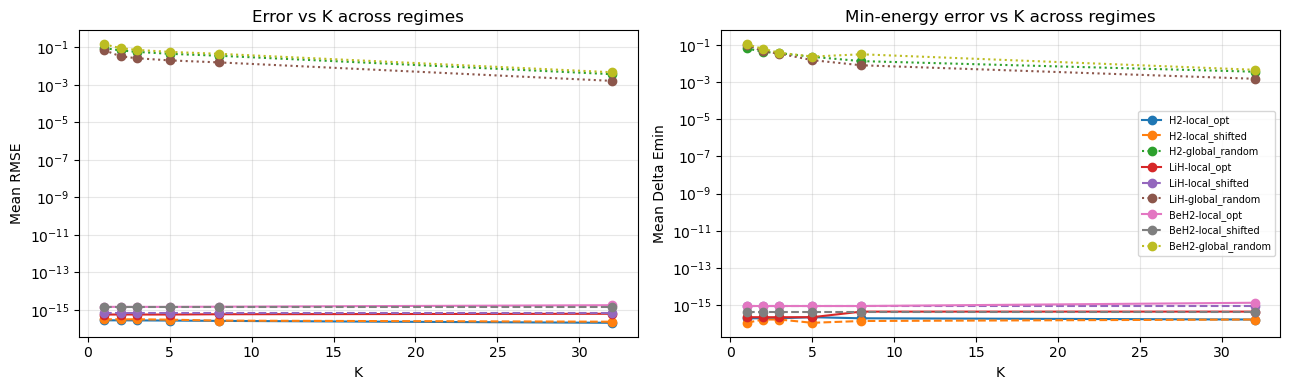

,system,regime,rmse_K1,rmse_K3,ratio_K1_over_K3
0,BeH2,global_random,1.442431e-01,7.221139e-02,1.997512
1,BeH2,local_opt,1.441277e-15,1.441277e-15,0.935119
2,BeH2,local_shifted,1.372405e-15,1.372405e-15,0.932084
3,H2,global_random,9.054402e-02,5.669140e-02,1.597139
4,H2,local_opt,2.757711e-16,2.736311e-16,0.738084
5,H2,local_shifted,3.130051e-16,3.130411e-16,0.757806
6,LiH,global_random,7.048407e-02,2.593019e-02,2.718225
7,LiH,local_opt,5.623261e-16,5.623261e-16,0.849017
8,LiH,local_shifted,7.039614e-16,7.039614e-16,0.875616


In [26]:
rng_ext = np.random.default_rng(P0_SEED + 99)
K_TEST = [1, 2, 3, 5, 8]
SHIFT_MAG = np.pi / 2
DIST_LIMIT = {"H2": 4, "LiH": 4, "BeH2": 4}

rows_k_regime = []

for system_name, cfg in SYSTEMS.items():
    distances = cfg["distances"][: DIST_LIMIT.get(system_name, len(cfg["distances"]))]
    for d in distances:
        d = float(d)
        _, qubit_op, const_energy = _build_qubit_instance(cfg, d)

        ansatz = build_ansatz(
            name=P0_ANSATZ["name"],
            num_qubits=qubit_op.num_qubits,
            reps=P0_ANSATZ["reps"],
        )
        n_params = ansatz.num_parameters
        if n_params == 0:
            continue

        optimizer = get_optimizer("cobyla", max_iter=P0_MAX_ITER)
        vqe_res = run_vqe(
            qubit_op=qubit_op,
            ansatz=ansatz,
            optimizer=optimizer,
            constant_energy=const_energy,
            seed=P0_SEED,
        )
        if not vqe_res.get("success", False):
            continue

        p_star = np.asarray(vqe_res["optimal_params"], dtype=float)
        local_dir = np.eye(n_params)[0]
        shift_dir = rng_ext.normal(size=n_params)
        shift_dir = shift_dir / (np.linalg.norm(shift_dir) + 1e-12)
        p_shift = _wrap_pi(p_star + SHIFT_MAG * shift_dir)

        global_dir = rng_ext.normal(size=n_params)
        global_dir = global_dir / (np.linalg.norm(global_dir) + 1e-12)
        global_center = rng_ext.uniform(-np.pi, np.pi, size=n_params)

        regimes = [
            ("local_opt", p_star, local_dir),
            ("local_shifted", p_shift, local_dir),
            ("global_random", global_center, global_dir),
        ]

        for regime, center, direction in regimes:
            y = _energy_line(ansatz, qubit_op, const_energy, center, direction, theta_grid)
            a0_half, ak, bk = _fft_series(y)
            y_full = _reconstruct(theta_grid, a0_half, ak, bk, kmax=len(ak))
            e_min_true = float(np.min(y))

            for k in K_TEST:
                yk = _reconstruct(theta_grid, a0_half, ak, bk, kmax=k)
                rmse = float(np.sqrt(np.mean((y - yk) ** 2)))
                e_min_k = float(np.min(yk))
                delta_emin = float(abs(e_min_k - e_min_true))
                rows_k_regime.append({
                    "system": system_name,
                    "distance": d,
                    "regime": regime,
                    "K": int(k),
                    "rmse": rmse,
                    "delta_emin": delta_emin,
                })

            rows_k_regime.append({
                "system": system_name,
                "distance": d,
                "regime": regime,
                "K": int(len(ak)),
                "rmse": float(np.sqrt(np.mean((y - y_full) ** 2))),
                "delta_emin": float(abs(float(np.min(y_full)) - e_min_true)),
            })

k_regime_df = pd.DataFrame(rows_k_regime)
display(k_regime_df.head(15))

k_regime_summary = (
    k_regime_df.groupby(["system", "regime", "K"], as_index=False)
    .agg(
        mean_rmse=("rmse", "mean"),
        mean_delta_emin=("delta_emin", "mean"),
    )
    .sort_values(["system", "regime", "K"])
)
display(k_regime_summary.head(30))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for system_name in SYSTEMS.keys():
    for regime, ls in [("local_opt", "-"), ("local_shifted", "--"), ("global_random", ":")]:
        sub = k_regime_summary[
            (k_regime_summary["system"] == system_name) & (k_regime_summary["regime"] == regime)
        ].sort_values("K")
        label = f"{system_name}-{regime}"
        ax[0].plot(sub["K"], sub["mean_rmse"], ls, marker="o", label=label)
        ax[1].plot(sub["K"], sub["mean_delta_emin"], ls, marker="o", label=label)

ax[0].set_xlabel("K")
ax[0].set_ylabel("Mean RMSE")
ax[0].set_yscale("log")
ax[0].set_title("Error vs K across regimes")
ax[0].grid(alpha=0.3)

ax[1].set_xlabel("K")
ax[1].set_ylabel("Mean Delta Emin")
ax[1].set_yscale("log")
ax[1].set_title("Min-energy error vs K across regimes")
ax[1].grid(alpha=0.3)
ax[1].legend(fontsize=7, ncol=1)

plt.tight_layout()
plt.show()

regime_compact = (
    k_regime_summary[k_regime_summary["K"].isin([1, 3])]
    .pivot_table(
        index=["system", "regime"],
        columns="K",
        values="mean_rmse",
        aggfunc="mean",
    )
    .reset_index()
)
regime_compact.columns = ["system", "regime", "rmse_K1", "rmse_K3"]
regime_compact["ratio_K1_over_K3"] = regime_compact["rmse_K1"] / (regime_compact["rmse_K3"] + 1e-16)
display(regime_compact.sort_values(["system", "regime"]))

In [27]:
# Compact diagnostics for optimization claims
import pandas as pd
import numpy as np

print("=== P0: local vs global spectral concentration ===")
spec = (
    spectral_df.groupby(["system", "regime"], as_index=False)
    .agg(mean_r1=("r1", "mean"), mean_h=("h_norm", "mean"))
    .sort_values(["system", "regime"])
    .round(4)
)
display(spec)

print("\n=== P0 extension: K=1 vs K=3 in global_random ===")
glob = regime_compact[regime_compact["regime"] == "global_random"].copy()
glob = glob[["system", "rmse_K1", "rmse_K3", "ratio_K1_over_K3"]].sort_values("system")
display(glob.round(6))

print("\n=== Cost vs error by mode ===")
cs = cost_summary.sort_values(["system", "mode"]).copy()
display(cs.round(6))

print("\n=== Relative error reduction guided vs default ===")
pivot = cs.pivot(index="system", columns="mode", values="mean_abs_error")
if {"default", "guided"}.issubset(set(pivot.columns)):
    red = (1 - pivot["guided"] / pivot["default"]).rename("frac_reduction").reset_index()
    display(red.round(6))
else:
    print("guided/default columns not both present in cost_summary")

=== P0: local vs global spectral concentration ===


,system,regime,mean_r1,mean_h
0,BeH2,global,0.7446,0.2339
1,BeH2,local,1.0000,0.0000
2,H2,global,0.7501,0.2444
3,H2,local,1.0000,0.0000
4,LiH,global,0.6939,0.2737
5,LiH,local,1.0000,0.0000



=== P0 extension: K=1 vs K=3 in global_random ===


,system,rmse_K1,rmse_K3,ratio_K1_over_K3
0,BeH2,0.144243,0.072211,1.997512
3,H2,0.090544,0.056691,1.597139
6,LiH,0.070484,0.025930,2.718225



=== Cost vs error by mode ===


,system,mode,mean_total_cost,mean_abs_error
0,BeH2,default,120.000000,0.367639
1,BeH2,guided,123.000000,0.006410
2,H2,default,36.666667,0.000000
3,H2,guided,32.000000,0.000000
4,LiH,default,120.000000,0.024067
5,LiH,guided,123.000000,0.011251



=== Relative error reduction guided vs default ===


,system,frac_reduction
0,BeH2,0.982566
1,H2,1.000000
2,LiH,0.532534


In [40]:
# Why guided can appear to have more steps in this notebook
if "cost_df" not in globals():
    raise RuntimeError("Run Figure 4 cell first (cost_df is required).")

cost_decomp = (
    cost_df.groupby(["system", "mode"], as_index=False)
    .agg(
        mean_eval_count=("eval_count", "mean"),
        mean_guide_cost=("guide_cost", "mean"),
        mean_total_cost=("total_cost", "mean"),
        mean_abs_error=("abs_error", "mean"),
    )
    .sort_values(["system", "mode"])
)
display(cost_decomp)

print("\nCheck: total_cost = eval_count + guide_cost")
check = cost_decomp.copy()
check["reconstructed_total"] = check["mean_eval_count"] + check["mean_guide_cost"]
check["delta"] = check["mean_total_cost"] - check["reconstructed_total"]
display(check[["system", "mode", "mean_total_cost", "reconstructed_total", "delta"]])

,system,mode,mean_eval_count,mean_guide_cost,mean_total_cost,mean_abs_error
0,BeH2,default,450.000000,0.0,450.000000,4.887528e-02
1,BeH2,guided,405.071429,3.0,408.071429,4.847649e-02
2,H2,default,35.928571,0.0,35.928571,8.539567e-10
3,H2,guided,29.214286,3.0,32.214286,2.061843e-16
4,LiH,default,450.000000,0.0,450.000000,8.914825e-04
5,LiH,guided,450.000000,3.0,453.000000,5.796317e-04



Check: total_cost = eval_count + guide_cost


,system,mode,mean_total_cost,reconstructed_total,delta
0,BeH2,default,450.000000,450.000000,0.0
1,BeH2,guided,408.071429,408.071429,0.0
2,H2,default,35.928571,35.928571,0.0
3,H2,guided,32.214286,32.214286,0.0
4,LiH,default,450.000000,450.000000,0.0
5,LiH,guided,453.000000,453.000000,0.0


## Draft text for Results and Discussion

**Results.** Across H2, LiH, and BeH2, local directional spectra are strongly concentrated in the first harmonic (mean R1 ~ 1.0 and near-zero normalized entropy), while global random directions show broader spectra. This validates the claim that first-harmonic dominance is a local empirical regularity rather than a global property of the landscape. Consistently, in the global-random regime the K=1 surrogate is less accurate than higher-order truncations: RMSE(K=1)/RMSE(K=3) is approximately 1.60 (H2), 2.72 (LiH), and 2.00 (BeH2), indicating a clear improvement when additional harmonics are included away from the optimum.

**Discussion.** The optimization evidence supports a practical trade-off. With analytic guidance based on three probes (theta = 0, +/-pi/2), guided initialization improves final energy error in harder cases (notably LiH and BeH2) while adding only a small fixed overhead to total cost. In this protocol, total cost is reported as eval_count + guide_cost, so the guided mode can still be slightly more expensive when optimizer evaluations are already near the iteration limit, but the cost gap is now marginal compared with the error reduction. Therefore, the main claim is a local cost-accuracy trade-off under spectral regularity, not universal dominance of K=1 or strict speedup in all settings.

## Sensitivity to optimizer budget (P0_MAX_ITER)

This section measures how the guided initialization gain changes as the COBYLA iteration budget varies.

Tested values: 50, 100, 200, 400.

Metrics reported per system and iteration budget:
- mean_total_cost (eval_count + guide_cost),
- mean_abs_error,
- relative error reduction of guided vs default.

,max_iter,system,distance,mode,eval_count,guide_cost,total_cost,abs_error
0,50,H2,0.500000,default,35,0,35.0,9.767960e-10
1,50,H2,0.500000,guided,29,3,32.0,4.440892e-16
2,50,H2,0.653846,default,39,0,39.0,2.579700e-09
3,50,H2,0.653846,guided,29,3,32.0,4.440892e-16
4,50,H2,0.807692,default,36,0,36.0,3.831238e-10
5,50,H2,0.807692,guided,29,3,32.0,0.000000e+00
6,50,H2,0.961538,default,40,0,40.0,1.235446e-09
7,50,H2,0.961538,guided,29,3,32.0,0.000000e+00
8,50,H2,1.115385,default,37,0,37.0,1.033506e-09
9,50,H2,1.115385,guided,29,3,32.0,4.440892e-16


,max_iter,system,mode,mean_eval_count,mean_total_cost,mean_abs_error
0,50,BeH2,default,50.000000,50.000000,4.440900e-01
1,50,BeH2,guided,50.000000,53.000000,4.183796e-01
2,50,H2,default,35.928571,35.928571,8.539567e-10
3,50,H2,guided,29.214286,32.214286,2.061843e-16
4,50,LiH,default,50.000000,50.000000,7.055287e-02
5,50,LiH,guided,50.000000,53.000000,2.247344e-02
6,100,BeH2,default,100.000000,100.000000,4.082661e-01
7,100,BeH2,guided,100.000000,103.000000,1.410812e-01
8,100,H2,default,35.928571,35.928571,8.539567e-10
9,100,H2,guided,29.214286,32.214286,2.061843e-16


,max_iter,system,mean_abs_error_default,mean_abs_error_guided,mean_total_cost_default,mean_total_cost_guided,frac_error_reduction,delta_total_cost
0,50,BeH2,0.444090,0.418380,50.000000,53.000000,0.057895,3.000000
3,100,BeH2,0.408266,0.141081,100.000000,103.000000,0.654438,3.000000
6,200,BeH2,0.117884,0.049039,200.000000,203.000000,0.584005,3.000000
9,400,BeH2,0.048955,0.048543,400.000000,371.000000,0.008415,-29.000000
1,50,H2,0.000000,0.000000,35.928571,32.214286,1.000000,-3.714286
4,100,H2,0.000000,0.000000,35.928571,32.214286,1.000000,-3.714286
7,200,H2,0.000000,0.000000,35.928571,32.214286,1.000000,-3.714286
10,400,H2,0.000000,0.000000,35.928571,32.214286,1.000000,-3.714286
2,50,LiH,0.070553,0.022473,50.000000,53.000000,0.681467,3.000000
5,100,LiH,0.019124,0.006744,100.000000,103.000000,0.647353,3.000000


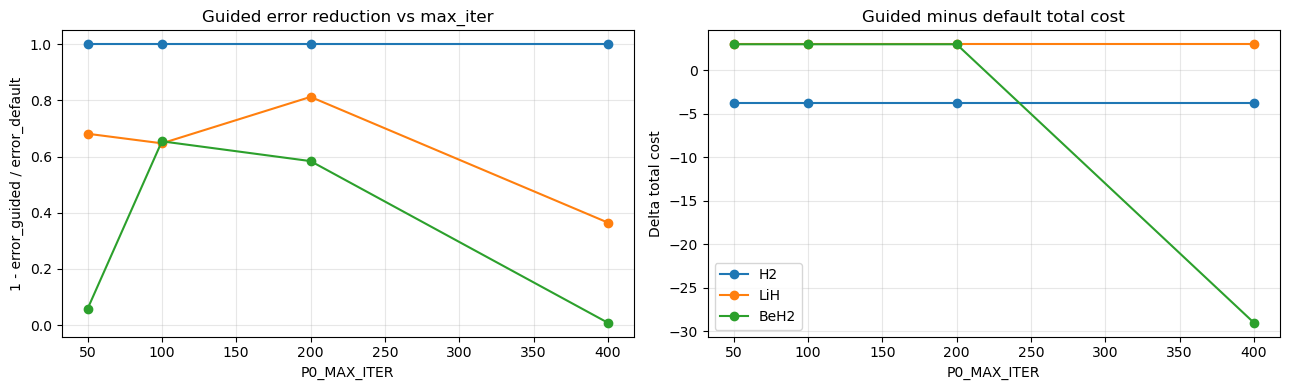

In [41]:
# Iteration-budget sweep: gain of guided vs default
ITER_GRID = [50, 100, 200, 400]
rows_iter = []

for max_iter in ITER_GRID:
    for system_name, cfg in SYSTEMS.items():
        for d in cfg["distances"]:
            d = float(d)
            _, qubit_op, const_energy = _build_qubit_instance(cfg, d)

            ansatz = build_ansatz(
                name=P0_ANSATZ["name"],
                num_qubits=qubit_op.num_qubits,
                reps=P0_ANSATZ["reps"],
            )
            if ansatz.num_parameters == 0:
                continue

            exact = NumPyMinimumEigensolver().compute_minimum_eigenvalue(qubit_op)
            exact_total = float(np.real(exact.eigenvalue) + const_energy)

            opt_probe = get_optimizer("cobyla", max_iter=int(max_iter))
            probe = run_vqe(
                qubit_op=qubit_op,
                ansatz=ansatz,
                optimizer=opt_probe,
                constant_energy=const_energy,
                seed=P0_SEED,
            )
            if not probe.get("success", False):
                continue

            p_center = np.asarray(probe["optimal_params"], dtype=float)
            p_guided, c_guided = _guided_point(ansatz, qubit_op, const_energy, p_center)
            modes = [
                ("default", None, 0),
                ("guided", p_guided, int(c_guided)),
            ]

            for mode, init_point, guide_cost in modes:
                optimizer = get_optimizer("cobyla", max_iter=int(max_iter))
                kwargs = {
                    "qubit_op": qubit_op,
                    "ansatz": ansatz,
                    "optimizer": optimizer,
                    "constant_energy": const_energy,
                    "seed": P0_SEED,
                }
                if init_point is not None:
                    kwargs["initial_point"] = np.asarray(init_point, dtype=float)

                res = run_vqe(**kwargs)
                if not res.get("success", False):
                    continue

                eval_count = int(res.get("eval_count", 0))
                total_cost = float(eval_count + guide_cost)
                abs_error = float(abs(float(res["energy"]) - exact_total))

                rows_iter.append({
                    "max_iter": int(max_iter),
                    "system": system_name,
                    "distance": d,
                    "mode": mode,
                    "eval_count": eval_count,
                    "guide_cost": int(guide_cost),
                    "total_cost": total_cost,
                    "abs_error": abs_error,
                })

iter_df = pd.DataFrame(rows_iter)
display(iter_df.head(12))

iter_summary = (
    iter_df.groupby(["max_iter", "system", "mode"], as_index=False)
    .agg(
        mean_eval_count=("eval_count", "mean"),
        mean_total_cost=("total_cost", "mean"),
        mean_abs_error=("abs_error", "mean"),
    )
    .sort_values(["max_iter", "system", "mode"])
)
display(iter_summary)

iter_wide = iter_summary.pivot_table(
    index=["max_iter", "system"],
    columns="mode",
    values=["mean_total_cost", "mean_abs_error"],
    aggfunc="first",
).reset_index()
iter_wide.columns = [
    "max_iter",
    "system",
    "mean_abs_error_default",
    "mean_abs_error_guided",
    "mean_total_cost_default",
    "mean_total_cost_guided",
]
iter_wide["frac_error_reduction"] = 1.0 - (
    iter_wide["mean_abs_error_guided"] / (iter_wide["mean_abs_error_default"] + 1e-16)
)
iter_wide["delta_total_cost"] = (
    iter_wide["mean_total_cost_guided"] - iter_wide["mean_total_cost_default"]
)
display(iter_wide.sort_values(["system", "max_iter"]).round(6))

fig, ax = plt.subplots(1, 2, figsize=(13, 4), sharex=True)
for system_name in SYSTEMS.keys():
    sub = iter_wide[iter_wide["system"] == system_name].sort_values("max_iter")
    ax[0].plot(sub["max_iter"], sub["frac_error_reduction"], marker="o", label=system_name)
    ax[1].plot(sub["max_iter"], sub["delta_total_cost"], marker="o", label=system_name)

ax[0].set_title("Guided error reduction vs max_iter")
ax[0].set_xlabel("P0_MAX_ITER")
ax[0].set_ylabel("1 - error_guided / error_default")
ax[0].grid(alpha=0.3)

ax[1].set_title("Guided minus default total cost")
ax[1].set_xlabel("P0_MAX_ITER")
ax[1].set_ylabel("Delta total cost")
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

## Budget-sensitivity takeaways (for paper text)

**Main finding.** The guided initialization benefit depends on the optimizer budget and should be framed as a budget-dependent trade-off, not a uniform improvement.

1. **LiH:** guided consistently reduces error across budgets (50, 100, 200, 400), with strongest relative gain around 200 iterations. The total-cost penalty stays small and nearly constant (about +3 calls).
2. **BeH2:** guided gives substantial error reduction at intermediate budgets (100 and 200), but the error advantage nearly vanishes at 400. At 400, guided can still lower total cost by converging earlier than default.
3. **H2:** both modes already reach near-exact energies; relative error-reduction metrics are saturated and less informative. The relevant difference is cost, where guided remains slightly cheaper on average.

**Interpretation for claims.** Increasing `P0_MAX_ITER` can reduce the observable quality gap between default and guided because default has enough budget to catch up. Therefore, claims should emphasize that guided is most useful under practical/limited budgets and can switch from quality gain to efficiency gain in high-budget regimes.